# Best vs iHub Audit Viewer

This notebook reads the preserved **2,000-order benchmark CSV**. It does not rerun the benchmark. Use it to separate iHub policy violations, confirm Best has no policy-compliant losses, review all 67 Best wins, then inspect any winning Order ID with the original inputs and validated 3D packing plan.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "notebooks"))

from benchmark_solver_modes import _inputs
from bin_packing_3d import result_tables, solve_order, visualize_result

CSV_PATH = ROOT / "notebooks" / "artifacts" / "benchmark_2000_best_vs_ihub.csv"
DATA_PATH = ROOT / "data" / "raw" / "data_samples_v2.json"

audit = pd.read_csv(CSV_PATH)
records = json.loads(DATA_PATH.read_text(encoding="utf-8"))
records_by_order = {record["input"]["OrderId"]: record for record in records}

display(Markdown(f"## Full benchmark: {len(audit):,} orders"))
display(audit)


## Full benchmark: 2,000 orders

,order_id,physical_items,candidate_boxes,ihub_boxes,ihub_cartons,ihub_external_volume_mm3,ihub_largest_carton_volume_mm3,ihub_latency_ms,ihub_box9_over_fill_cap,fast_boxes,...,best_cartons,best_external_volume_mm3,best_largest_carton_volume_mm3,best_runtime_ms,best_optimality_proven,best_search_status,best_valid,best_vs_ihub,best_win,best_win_reason
0,1,4,6,Box4,1,13260000.0,13260000.0,410.02,False,Box4,...,1,13260000.0,13260000.0,16.047593,True,optimal,True,equal,False,Equal on all 3 criteria
1,2,11,6,Box5,1,20774000.0,20774000.0,194.64,False,Box5,...,1,20774000.0,20774000.0,47.749097,True,optimal,True,equal,False,Equal on all 3 criteria
2,3,9,6,Box5,1,20774000.0,20774000.0,186.93,False,Box5,...,1,20774000.0,20774000.0,30.416872,True,optimal,True,equal,False,Equal on all 3 criteria
3,4,3,6,Box2,1,5278500.0,5278500.0,188.88,False,Box2,...,1,5278500.0,5278500.0,4.169795,True,optimal,True,equal,False,Equal on all 3 criteria
4,5,5,6,Box4,1,13260000.0,13260000.0,188.94,False,Box4,...,1,13260000.0,13260000.0,17.079712,True,optimal,True,equal,False,Equal on all 3 criteria
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,6,6,Box5,1,20774000.0,20774000.0,460.55,False,Box5,...,1,13260000.0,13260000.0,18.401148,True,optimal,True,better,True,2. Smaller largest carton
1996,1997,10,6,Box9,1,42504000.0,42504000.0,442.73,False,Box9,...,1,42504000.0,42504000.0,38.642491,True,optimal,True,equal,False,Equal on all 3 criteria
1997,1998,8,6,Box6,1,24752000.0,24752000.0,510.23,False,Box6,...,1,24752000.0,24752000.0,29.909816,True,optimal,True,equal,False,Equal on all 3 criteria
1998,1999,6,6,Box5,1,20774000.0,20774000.0,435.00,False,Box5,...,1,13260000.0,13260000.0,17.384793,True,optimal,True,better,True,2. Smaller largest carton


In [2]:
policy_violations = audit[audit["ihub_box9_over_fill_cap"]].copy()
policy_violations["policy_finding"] = "iHub Box9 exceeds supplied fill cap"
policy_violations["best_fix"] = policy_violations.apply(
    lambda row: f"Valid Best re-pack: {row['best_boxes']}" if row["best_valid"] else "REVIEW: Best invalid", axis=1
)
eligible = audit[~audit["ihub_box9_over_fill_cap"]].copy()
wins = eligible[eligible["best_win"]].copy()
losses = eligible[eligible["best_vs_ihub"] == "worse"].copy()

display(Markdown(
    f"## Fair-comparison population\n"
    f"- **{len(policy_violations):,}** iHub results violate the supplied Box9 fill policy and are flagged separately.\n"
    f"- **{len(eligible):,}** orders remain for like-for-like optimization comparison.\n"
    f"- **{len(wins):,}** orders are better with Best.\n"
    f"- **{len(losses):,}** policy-compliant orders are worse with Best."
))

display(Markdown("### iHub policy violations and Best correction"))
display(policy_violations[[
    "order_id", "physical_items", "ihub_boxes", "policy_finding",
    "best_boxes", "best_cartons", "best_valid", "best_fix",
]])

assert len(losses) == 0, "Best has policy-compliant losses. Review before presenting."
assert len(wins) == 67, f"Expected 67 Best wins, found {len(wins)}."

display(Markdown("### Why the 67 wins are better"))
display(wins["best_win_reason"].value_counts().rename_axis("winning_criterion").to_frame("orders"))

display(Markdown("## The 67 Best wins"))
display(wins[[
    "order_id", "physical_items", "ihub_boxes", "best_boxes",
    "ihub_cartons", "best_cartons",
    "ihub_largest_carton_volume_mm3", "best_largest_carton_volume_mm3",
    "ihub_external_volume_mm3", "best_external_volume_mm3",
    "best_win_reason", "best_runtime_ms", "best_optimality_proven",
]])


## Fair-comparison population
- **183** iHub results violate the supplied Box9 fill policy and are flagged separately.
- **1,817** orders remain for like-for-like optimization comparison.
- **67** orders are better with Best.
- **0** policy-compliant orders are worse with Best.

### iHub policy violations and Best correction

,order_id,physical_items,ihub_boxes,policy_finding,best_boxes,best_cartons,best_valid,best_fix
39,40,10,"Box9,Box4",iHub Box9 exceeds supplied fill cap,"Box4,Box9",2,True,"Valid Best re-pack: Box4,Box9"
69,70,17,Box9,iHub Box9 exceeds supplied fill cap,"Box5,Box6",2,True,"Valid Best re-pack: Box5,Box6"
73,74,8,"Box9,Box4",iHub Box9 exceeds supplied fill cap,"Box4,Box9",2,True,"Valid Best re-pack: Box4,Box9"
83,84,10,Box9,iHub Box9 exceeds supplied fill cap,"Box6,Box6",2,True,"Valid Best re-pack: Box6,Box6"
88,89,10,Box9,iHub Box9 exceeds supplied fill cap,"Box5,Box6",2,True,"Valid Best re-pack: Box5,Box6"
...,...,...,...,...,...,...,...,...
1966,1967,21,"Box9,Box2",iHub Box9 exceeds supplied fill cap,"Box4,Box9",2,True,"Valid Best re-pack: Box4,Box9"
1967,1968,21,"Box9,Box2",iHub Box9 exceeds supplied fill cap,"Box4,Box9",2,True,"Valid Best re-pack: Box4,Box9"
1968,1969,21,"Box9,Box2",iHub Box9 exceeds supplied fill cap,"Box4,Box9",2,True,"Valid Best re-pack: Box4,Box9"
1975,1976,19,Box9,iHub Box9 exceeds supplied fill cap,"Box6,Box6",2,True,"Valid Best re-pack: Box6,Box6"


### Why the 67 wins are better

,orders
winning_criterion,
2. Smaller largest carton,63
3. Lower total carton volume,2
1. Fewer cartons,2


## The 67 Best wins

,order_id,physical_items,ihub_boxes,best_boxes,ihub_cartons,best_cartons,ihub_largest_carton_volume_mm3,best_largest_carton_volume_mm3,ihub_external_volume_mm3,best_external_volume_mm3,best_win_reason,best_runtime_ms,best_optimality_proven
30,31,6,"Box9,Box5","Box8,Box9",2,2,42504000.0,42504000.0,63278000.0,57120000.0,3. Lower total carton volume,174.741578,True
185,186,5,Box5,Box8,1,1,20774000.0,14616000.0,20774000.0,14616000.0,2. Smaller largest carton,13.885384,True
236,237,6,Box6,Box5,1,1,24752000.0,20774000.0,24752000.0,20774000.0,2. Smaller largest carton,13.806036,True
263,264,6,Box9,Box6,1,1,42504000.0,24752000.0,42504000.0,24752000.0,2. Smaller largest carton,14.957082,True
320,321,15,"Box9,Box8",Box9,2,1,42504000.0,42504000.0,57120000.0,42504000.0,1. Fewer cartons,68.887938,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1805,1806,7,Box9,Box6,1,1,42504000.0,24752000.0,42504000.0,24752000.0,2. Smaller largest carton,17.779729,True
1808,1809,8,Box5,Box8,1,1,20774000.0,14616000.0,20774000.0,14616000.0,2. Smaller largest carton,25.135209,True
1831,1832,5,Box5,Box8,1,1,20774000.0,14616000.0,20774000.0,14616000.0,2. Smaller largest carton,11.451170,True
1995,1996,6,Box5,Box4,1,1,20774000.0,13260000.0,20774000.0,13260000.0,2. Smaller largest carton,18.401148,True


## Inspect any of the 67 wins

Set an Order ID from the table above. The helper immediately states the winning criterion, shows the original item dimensions and `VerticalRotation` permission, reruns Best using that order's supplied policy, shows the validated carton/XYZ placement tables, and renders the 3D packing plan.

# Order 31: 3. Lower total carton volume
**iHub:** Box9,Box5 | 2 carton(s) | largest 42,504,000 mm³ | total 63,278,000 mm³  
**Best:** Box8,Box9 | 2 carton(s) | largest 42,504,000 mm³ | total 57,120,000 mm³

### Original order items and rotation permission

,Code,Quantity,Length,Width,Height,Weight,VerticalRotation
0,223,3,240,80,270.0,2.8000,1
1,328,1,180,100,270.0,1.3333,1
2,400,2,295,165,150.0,0.6458,1


### Best packing result: independently validated

Status,Strategy,Total cartons,Carton number,Carton,Box type,Item qty,Usable fill (%),Runtime (ms),Valid
success,best_fit,2,1,carton-1,Box8,2,72.49,174.966,True
success,best_fit,2,2,carton-2,Box9,4,59.26,174.966,True


### Exact packed orientation and XYZ coordinates

Carton,Box type,Item,Packed L (mm),Packed W (mm),Packed H (mm),X (mm),Y (mm),Z (mm),Volume (mm^3)
carton-1,Box8,223#2,270.0,80.0,240.0,0.0,80.0,0.0,5184000.0
carton-1,Box8,223#3,240.0,80.0,270.0,0.0,0.0,0.0,5184000.0
carton-2,Box9,223#1,80.0,270.0,240.0,0.0,0.0,0.0,5184000.0
carton-2,Box9,328#1,270.0,180.0,100.0,80.0,0.0,0.0,4860000.0
carton-2,Box9,400#1,165.0,295.0,150.0,245.0,0.0,100.0,7301250.0
carton-2,Box9,400#2,165.0,295.0,150.0,80.0,0.0,100.0,7301250.0


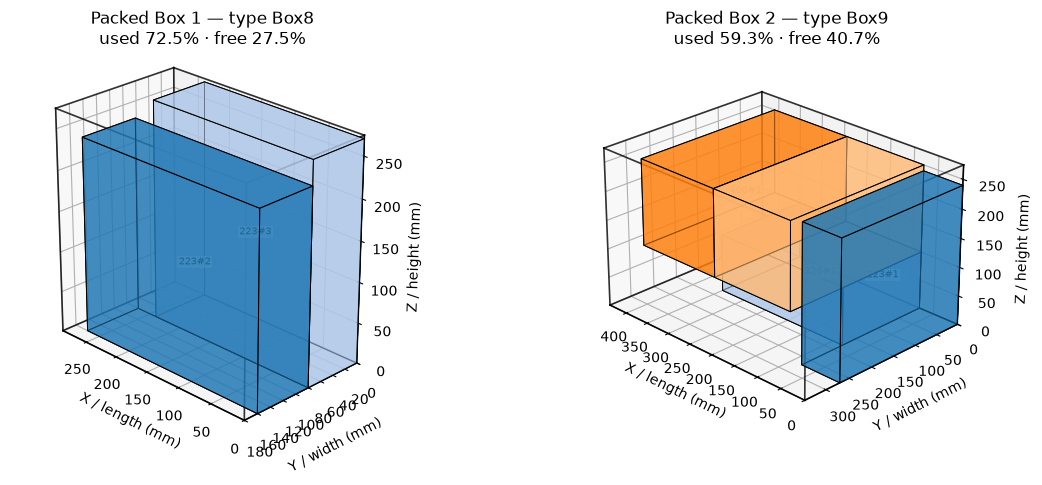

In [3]:
def inspect_win(order_id):
    match = wins[wins["order_id"] == order_id]
    if match.empty:
        raise ValueError(f"Order {order_id!r} is not one of the 67 Best wins.")
    row = match.iloc[0]
    record = records_by_order[order_id]
    order, boxes, solver_config = _inputs(record)

    display(Markdown(
        f"# Order {order_id}: {row['best_win_reason']}\n"
        f"**iHub:** {row['ihub_boxes']} | {int(row['ihub_cartons'])} carton(s) | "
        f"largest {int(row['ihub_largest_carton_volume_mm3']):,} mm³ | total {int(row['ihub_external_volume_mm3']):,} mm³  \n"
        f"**Best:** {row['best_boxes']} | {int(row['best_cartons'])} carton(s) | "
        f"largest {int(row['best_largest_carton_volume_mm3']):,} mm³ | total {int(row['best_external_volume_mm3']):,} mm³"
    ))

    item_rows = []
    for item in order["Items"]:
        item_rows.append({
            "Code": item["Code"], "Quantity": item["Quantity"],
            "Length": item["Length"], "Width": item["Width"], "Height": item["Height"],
            "Weight": item["Weight"], "VerticalRotation": item.get("VerticalRotation"),
        })
    display(Markdown("### Original order items and rotation permission"))
    display(pd.DataFrame(item_rows))

    result = solve_order(order, boxes, mode="best", **solver_config)
    if not result.validation.valid:
        raise AssertionError(result.validation.errors)
    summary, placements = result_tables(result)
    display(Markdown("### Best packing result: independently validated"))
    display(summary)
    display(Markdown("### Exact packed orientation and XYZ coordinates"))
    display(placements)
    visualize_result(result)
    return result

# Pick any Order ID from the 67-win table.
INSPECT_ORDER_ID = wins.iloc[0]["order_id"]
result = inspect_win(INSPECT_ORDER_ID)
